In [1]:
import pandas as pd
import os
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
data_fake = pd.read_csv("News_Dataset/Fake.csv")
data_true = pd.read_csv("News_Dataset/True.csv")

In [3]:
data_fake["class"] = 0
data_true["class"] = 1

In [4]:
data = pd.concat([data_fake, data_true], ignore_index=True)

In [5]:
data.shape

(44898, 5)

In [6]:
data.head()

,title,text,subject,date,class
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [7]:
data.columns

Index(['title', 'text', 'subject', 'date', 'class'], dtype='object')

In [8]:
data["content"] = data["title"] + " " + data["text"]

In [9]:
data.isnull().sum()

title      0
text       0
subject    0
date       0
class      0
content    0
dtype: int64

In [10]:
data.duplicated().sum()

np.int64(209)

In [11]:
print("Empty title:", (data["title"].str.strip() == "").sum())
print("Empty text:", (data["text"].str.strip() == "").sum())

Empty title: 0
Empty text: 631


In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   class    44898 non-null  int64 
 5   content  44898 non-null  object
dtypes: int64(1), object(5)
memory usage: 2.1+ MB


In [13]:
data = data.drop_duplicates()
data = data[data["text"].str.strip() != ""]

In [14]:
data.shape

(44058, 6)

In [15]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

data["content"] = data["content"].apply(clean_text)

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data["content"])
y = data["class"]

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
from sklearn.linear_model import LogisticRegression

In [19]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9893327280980481


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[4519   53]
 [  41 4199]]


In [23]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4572
           1       0.99      0.99      0.99      4240

    accuracy                           0.99      8812
   macro avg       0.99      0.99      0.99      8812
weighted avg       0.99      0.99      0.99      8812



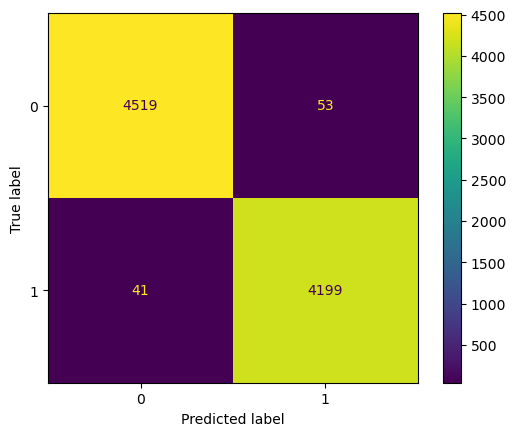

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

In [25]:
import joblib

joblib.dump(model, "logistic_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [26]:
X_test, y_test

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 1537899 stored elements and shape (8812, 5000)>,
 13423    0
 5040     0
 32779    1
 23441    0
 41105    1
         ..
 40658    1
 36719    1
 4528     0
 17679    0
 4092     0
 Name: class, Length: 8812, dtype: int64)

In [27]:
y_pred = model.predict(X_test)

In [28]:
# news = input("Enter news text: ")

# news_vector = vectorizer.transform([news])

# prediction = model.predict(news_vector)[0]

# if prediction == 0:
#     print("\n \n \nPrediction: FAKE NEWS")
# else:
#     print("\n \n \nPrediction: REAL NEWS")



In [29]:
pip install tavily-python

Note: you may need to restart the kernel to use updated packages.


In [30]:
from tavily import TavilyClient

tavily = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

In [31]:
# response = tavily.search(
#     # news = input("Enter news text: ")
#     query=input("enter search::\n"),
#     search_depth="advanced",
#     max_results=3
# )

# print(response)

In [32]:
# for result in response["results"]:
#     print("TITLE:", result["title"])
#     print("URL:", result["url"])
#     print("CONTENT:", result["content"][:500])
#     print("-" * 60)

In [33]:
# news = input("Enter news: ")

# response = tavily.search(
#     query=news,
#     search_depth="advanced",
#     max_results=3
# )

# for result in response["results"]:
#     print("\nTITLE:", result["title"])
#     print("URL:", result["url"])
#     print("CONTENT:", result["content"][:500])

In [34]:

# evidence = ""

# for result in response["results"]:
#     evidence += result["content"] + "\n"
    
# print(evidence[:3000])

In [35]:
# claim = news

# evidence = ""

# for result in response["results"]:
#     evidence += f"Source: {result['title']}\n"
#     evidence += f"Content: {result['content'][:1000]}\n\n"

# print("CLAIM:")
# print(claim)

# print("\nEVIDENCE:")
# print(evidence)

In [36]:
pip install google-genai

Note: you may need to restart the kernel to use updated packages.


In [37]:
from google import genai

client = genai.Client(api_key=os.getenv("GEMINI_API_KEY"))

In [38]:
# interaction = client.interactions.create(
#     model="gemini-3.1-flash-lite",
#     input="Explain fake news in one simple sentence."
# )

# print(interaction.output_text)

In [39]:
# prompt = f"""
# You are a fact-checking assistant.

# Claim:
# {news}

# Web Evidence:
# {evidence}

# Based only on the evidence, analyze the claim.

# Give your answer in this format:

# Verdict: TRUE, FALSE, or UNCERTAIN

# Explanation:
# Give a short and clear explanation.

# Sources:
# Mention the source titles used.
# """

# interaction = client.interactions.create(
#     model="gemini-3.1-flash-lite",
#     input=prompt
# )

# print(interaction.output_text)

In [40]:
logistic_model = joblib.load("logistic_model.pkl")
tfidf_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [41]:
# X_news = tfidf_vectorizer.transform([news])

# ml_prediction = logistic_model.predict(X_news)[0]

# print("ML Prediction:", ml_prediction)

In [42]:
news = input("Enter news:\n ")

# 1. ML Prediction
X_news = tfidf_vectorizer.transform([news])
ml_prediction = logistic_model.predict(X_news)[0]

if ml_prediction == 0:
    ml_result = "FAKE"
else:
    ml_result = "REAL"


# 2. Web Search
response = tavily.search(
    query=news,
    search_depth="advanced",
    max_results=3
)

evidence = ""

for result in response["results"]:
    evidence += f"""
Source: {result['title']}
URL: {result['url']}
Content: {result['content'][:1000]}
"""


# 3. Gemini
prompt = f"""
You are a fact-checking assistant.

User Claim:
{news}

Machine Learning Prediction:
{ml_result}

Web Evidence:
{evidence}

Analyze the claim using the web evidence.

Give the final answer in this format:

FINAL VERDICT: TRUE, FALSE, or UNCERTAIN

ML PREDICTION BY MODEL: {ml_result}

EXPLANATION:
Give a short and clear explanation based on the evidence.

SOURCES:
List the important source titles.
"""

interaction = client.interactions.create(
    model="gemini-3.1-flash-lite",
    input=prompt
)


# 4. Final Output
print("\n" + "="*40)
print("           FAKE NEWS Detection")
print("="*40)

print("\nYour News:")
print(news)

print("\n" + interaction.output_text)

print("\n" + "="*60)

Enter news:
  dinesh kumar is the real prime minister of india 



           FAKE NEWS Detection

Your News:
dinesh kumar is the real prime minister of india 

FINAL VERDICT: FALSE

ML PREDICTION BY MODEL: REAL

EXPLANATION:
The claim that Dinesh Kumar is the Prime Minister of India is factually incorrect. The provided evidence identifies Dinesh Kumar Singh as a former member of the Bihar Legislative Assembly and Dinesh K. Patnaik as an Indian diplomat (Ambassador). Neither individual holds the office of Prime Minister of India. The current Prime Minister of India is Narendra Modi.

SOURCES:
- Dinesh Kumar Singh - Wikipedia
- Dinesh Trivedi - Wikipedia
- Dinesh K. Patnaik (@DineshKPatnaik) / X




           FAKE NEWS Detection

Your News:
chief minister of uttar pradesh is amit shah

FINAL VERDICT: FALSE

ML PREDICTION BY MODEL: REAL

EXPLANATION:
The claim that Amit Shah is the Chief Minister of Uttar Pradesh is incorrect. According to multiple credible sources, including the official Bharatiya Janata Party Uttar Pradesh website and Wikipedia, Yogi Adityanath is the current Chief Minister of Uttar Pradesh and has been serving in this role since March 19, 2017. Amit Shah is the Union Minister of Home Affairs of India, not the Chief Minister of Uttar Pradesh.

SOURCES:
1. Uttar Pradesh Chief Ministers List 2026 - Full CM History (BankBazaar)
2. Chief Minister of Uttar Pradesh - Wikipedia
3. Shri Yogi Adityanath | Bharatiya Janata Party Uttar Pradesh

